# Introduction

In this notebook, we focus on data analysis on classification dataset for the following steps:
1. Display sample images from the dataset
2. Display the distribution of images across classes
3. Compute mean and standard deviation of the dataset
4. Detect blurred images using Laplacian variance
5. Get the shapes of the images in the dataset and visualize the distribution of image sizes in bins
6. Check the image channel unique values

### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import pandas as pd
import numpy as np

In [2]:
from nazi_symbols_classification.training.data_preparation import get_image_paths

### Get all the image paths from the classification dataset

In [3]:
dir_name = os.path.dirname(os.getcwd())
image_files = get_image_paths(f"{dir_name}/datasets/nazi-symbols-classification-original", 
                              ("train", ))
print(f"Total Images: {len(image_files)}")

Total Images: 3509


### Display sample images

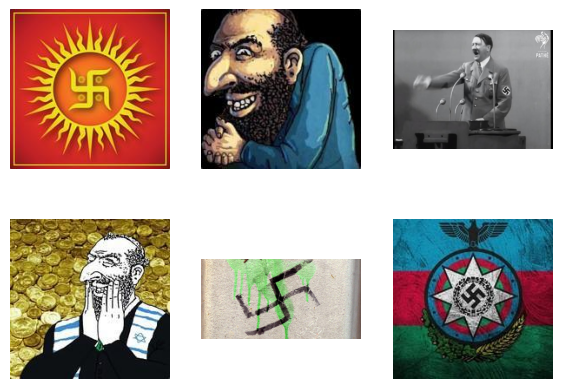

In [78]:
sample_images = random.sample(image_files, 6)
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
for i, ax_l in enumerate(axes):
    for j, ax in enumerate(ax_l):
        img_file = sample_images[i * 3 + j]
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
plt.savefig('nazi-symbols-classification-examples.png')
plt.show()

### Construct a DataFrame with image paths and labels, where labels are the parent directory names. 

As the dataset is structured in a way that each image is stored in a directory named after its label, we can extract the label from the image path.

In [79]:
labels = [os.path.basename(os.path.dirname(image_file)) for image_file in image_files]

Create a DataFrame with image paths and labels

In [80]:
df = pd.DataFrame({"path": image_files, "label": labels})
df.head()

,path,label
0,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
1,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
2,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
3,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
4,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute


organise the label names into a more readable format, replacing underscores with spaces and capitalizing the first letter of each word.

In [81]:
replacement_dict = dict(
    hitler_salute="Nazi salute", 
    british_union_of_fascist="Flash and circle", 
    doppelsiegrune="Doppelsiegrune",
    sturmabteilung_emblem="Sturmabteilung emblem",
    combat_18_emblem="Combat 18 emblem", 
    ss_skull="SS Skull",
    black_sun="Black Sun",
    hitler="Hitler", 
    judenstern="Yellow badge",
    golden_dawn="Golden Dawn",
    wolfsangel="Wolfsangel",
    celtic_cross="Celtic Cross",
    broken_sun_cross="Broken Sun Cross",
    hammerskins="Hammerskins emblem",
    national_rebirth_poland="National Rebirth of Poland emblem", 
    happy_merchant="The Happy Merchant", 
    kolovrat="Kolovrat",
    volksfront_emblem="Popular front emblem", 
    identitaere_bewegung_emblem="Identitarian movement emblem", 
    swastika="Swastika",
    atomwaffen="Atomwaffen Division emblem", 
    siegrune="Siegrune", 
    blood_honor_emblem="Blood & Honor emblem"
)

df["label"] = df.label.replace(replacement_dict)

In [82]:
def wrap_title(string, max_length):
    result = []
    string = string.split()
    temp = ""
    for word in string:
        if len(temp + word) > max_length:
            result.append(temp)
            temp = ""
        elif len(temp) > 0:
            temp += " "
        temp += word
    result.append(temp)
    return "\n".join(result)

wrap_title("Combat 18 emblem", 15)

'Combat 18 emblem'

In [83]:
df.label.unique().tolist(), len(df.label.unique())

(['Nazi salute',
  'Flash and circle',
  'Doppelsiegrune',
  'Sturmabteilung emblem',
  'Combat 18 emblem',
  'SS Skull',
  'Black Sun',
  'non-nazi',
  'Hitler',
  'Yellow badge',
  'Golden Dawn',
  'Wolfsangel',
  'Celtic Cross',
  'Broken Sun Cross',
  'Hammerskins emblem',
  'National Rebirth of Poland emblem',
  'The Happy Merchant',
  'Kolovrat',
  'Popular front emblem',
  'Identitarian movement emblem',
  'Swastika',
  'Atomwaffen Division emblem',
  'Siegrune',
  'Blood & Honor emblem'],
 24)

### Display sample images from each class

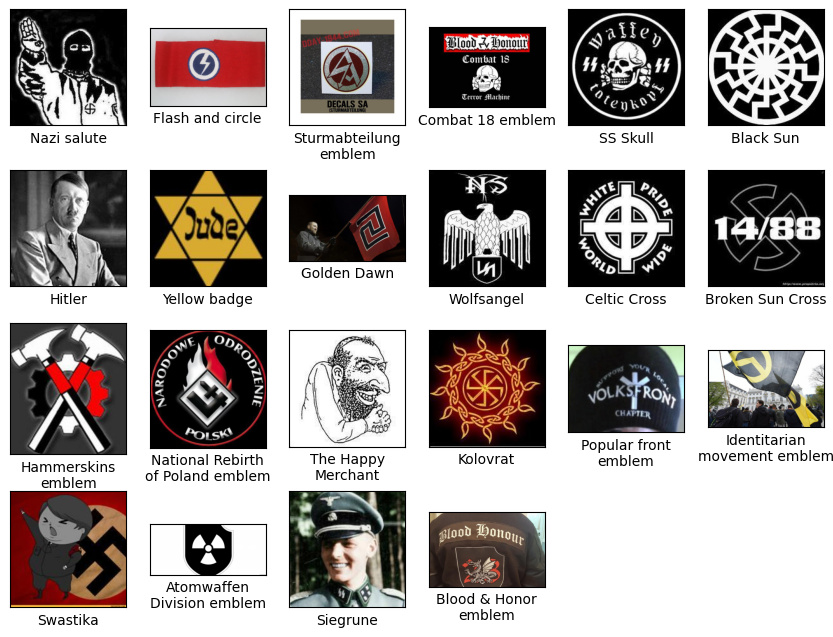

In [132]:
fig, axes = plt.subplots(4, 6, figsize=(10.5, 8))
unique_labels = df.label.unique().tolist()
unique_labels.remove('non-nazi')
unique_labels.remove('Doppelsiegrune')
displayed_image_names = []

for i, ax_l in enumerate(axes):
    for j, ax in enumerate(ax_l):
        if i * 6 + j >= len(unique_labels): 
            ax.axis("off")
            continue
        img_cls = unique_labels[i * 6 + j]
        if img_cls == "The Happy Merchant":
            img_file = f"{dir_name}/datasets/nazi-symbols-classification-original/train/happy_merchant/9bc2c7e52b007d50471a35afd01e9580ebbb4fc9_full_jpg.rf.4c8d8e359dfa1c07bc863b8c2bdebc2f.jpg"
            image_file_name = os.path.basename(img_file)
        else:
            img_file = random.sample(df[df.label == img_cls].path.tolist(), 1)[0]
            image_file_name = os.path.basename(img_file)
            while image_file_name in displayed_image_names:
                img_file = random.sample(df[df.label == img_cls].path.tolist(), 1)[0]
                image_file_name = os.path.basename(img_file)
        displayed_image_names.append(image_file_name)
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        # ax.axis("off")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(wrap_title(img_cls, 15))
plt.savefig('nazi-symbol-examples.png')
plt.show()

### Display the distribution of images across classes

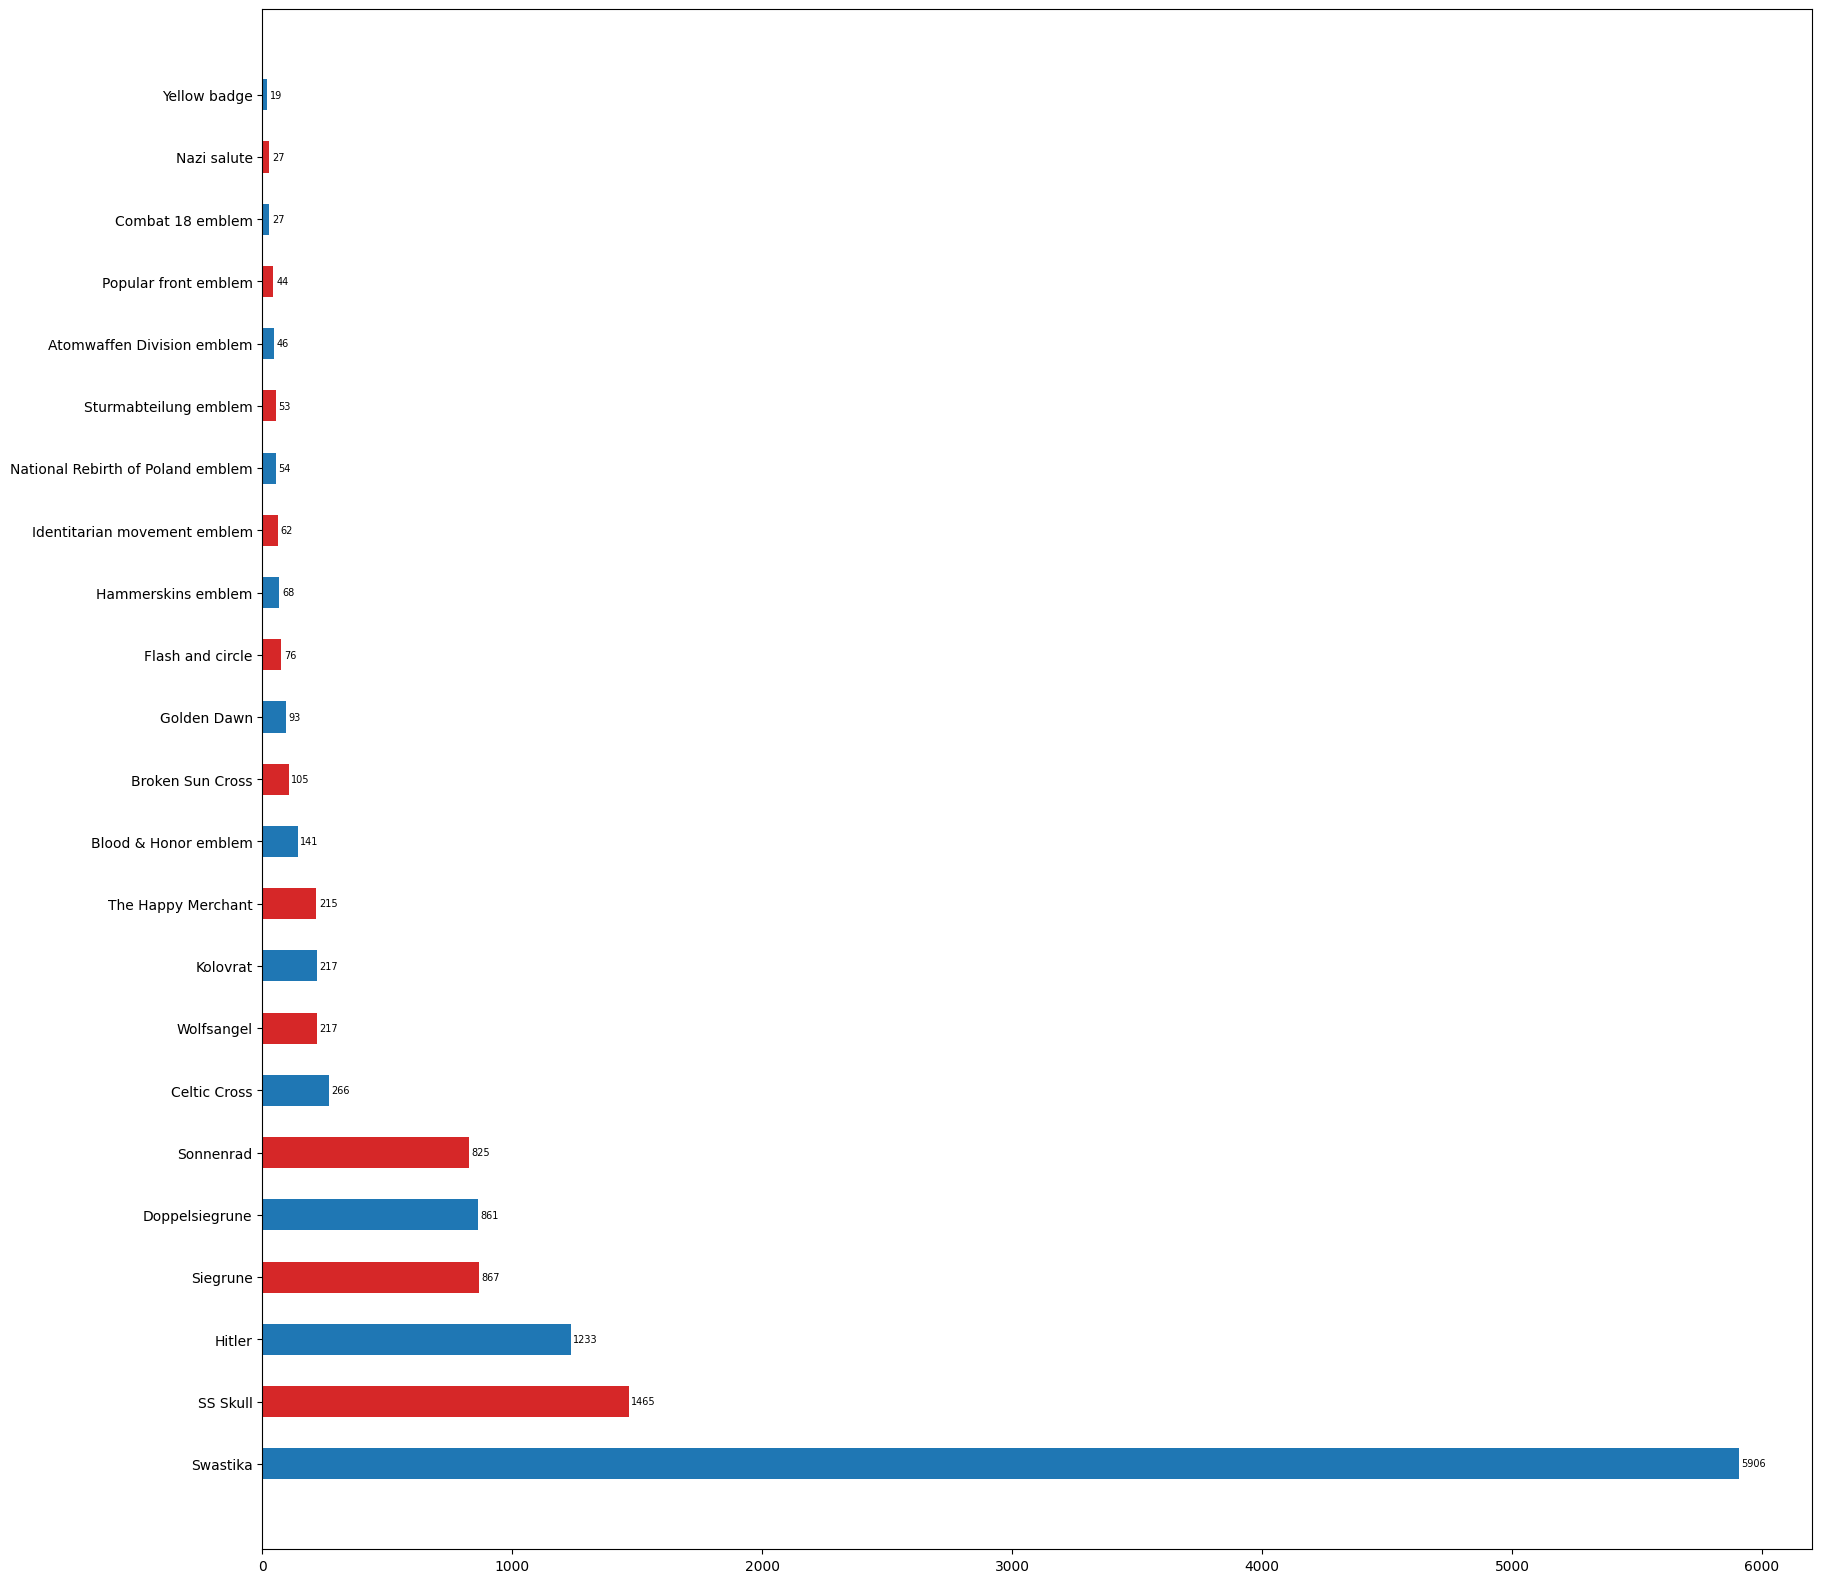

In [74]:
plt.figure(figsize=(20,20))

value_counts = df["label"].value_counts().to_dict()

img_cls, img_number = tuple(zip(*value_counts.items()))
width = 0.5
x = np.arange(len(value_counts))  # the label locations

bar_colors = ['tab:blue', 'tab:red']

rects = plt.barh(img_cls, img_number, width, color=bar_colors)
plt.bar_label(rects, padding=2, fontsize=7)

plt.ylabel='Number of images'
plt.title='Image Class Distribution'
plt.ylim = (0,7000)

plt.savefig('nazi-classification-distribution.png')
plt.show()

### Compute mean and standard deviation of the dataset

In [69]:
# Compute mean and std deviation across dataset
means, stds = [], []
for img_file in image_files:
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    means.append(np.mean(img, axis=(0, 1)))
    stds.append(np.std(img, axis=(0, 1)))

means = np.mean(means, axis=0)
stds = np.mean(stds, axis=0)
print(f"Mean: {means}, Std Dev: {stds}")

Mean: [0.44405632 0.44166248 0.4416103 ], Std Dev: [0.28905524 0.28752552 0.28753392]


### Detect blurred images using Laplacian variance

In [70]:
def detect_blur(img_path, threshold=100):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var < threshold

blurred_images = [f for f in image_files if detect_blur(f)]

In [71]:
print(f"Blurred Images: {len(blurred_images)}")

Blurred Images: 6883


### Get the shapes of the images in the dataset and visualize the distribution of image sizes in bins

In [53]:
naiz_files = [image for image in image_files if "non-nazi" not in image]


image_shapes = []
for img_file in naiz_files:
    img = cv2.imread(img_file)
    image_shapes.append(img.shape)
image_shapes_df = pd.DataFrame(data=image_shapes, columns=["width", "height", "channel"])

In [54]:
image_shapes_df.head()

,width,height,channel
0,184,184,3
1,184,184,3
2,184,184,3
3,184,184,3
4,184,184,3


In [55]:
image_shapes_df["min-size"] = image_shapes_df.apply(lambda x: min(x.width, x.height), axis=1)

In [21]:
max(image_shapes_df["min-size"].value_counts())

2030

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


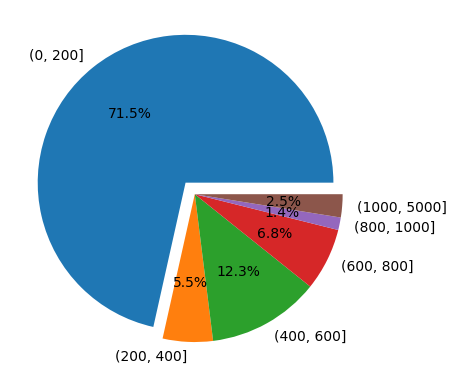

In [77]:
bins = [0,200,400,600,800,1000, 5000]
df = image_shapes_df.groupby(pd.cut(image_shapes_df['min-size'], bins=bins))[['min-size', 'channel']].count()
df["min-size"].plot(kind='pie', ylabel="", autopct='%1.1f%%', explode=(0.1, 0, 0, 0, 0, 0))
plt.savefig('image-size-distribution.png', dpi = 800)

In [59]:
df.to_csv("image-size-dist.csv")

check the image channel unique values

In [44]:
image_shapes_df['channel'].value_counts()

channel
3    3509
Name: count, dtype: int64

In [60]:
df

,min-size,channel
min-size,,
"(0, 200]",1671,1671
"(200, 400]",128,128
"(400, 600]",287,287
"(600, 800]",160,160
"(800, 1000]",32,32
"(1000, 5000]",59,59
